# 1. loop vs. vectorised

- Use the implemented best_split method and more vectorised method
- Compare **training time(secnonds)** and **memory usage(MB)** based on different **size**:[100, 500, 1000, 5000, 10000]

In [1]:
import numpy as np

def entropy(y):
    _, counts = np.unique(y, return_counts=True)  
    probs = counts / counts.sum()                 
    return -np.sum(probs * np.log2(probs + 1e-9)) 

def impurity_gain( y, y_left, y_right):
    return entropy(y) - (len(y_left)/len(y))*entropy(y_left) - (len(y_right)/len(y))*entropy(y_right)
    
def best_split( X, y):
    best_gain = -1                
    best_feat = None             
    best_thresh = None           

    features = np.arange(X.shape[1])
    
    for feat in features:                    
        thresholds = np.unique(X[:, feat])             
        for thresh in thresholds:                      

            left = y[X[:, feat] <= thresh]             
            right = y[X[:, feat] > thresh]            

            if len(left) == 0 or len(right) == 0:     
                continue
            
            gain = impurity_gain(y, left, right)

            if gain > best_gain:                       
                best_gain = gain
                best_feat = feat
                best_thresh = thresh

    return best_feat, best_thresh

def best_split_vectorised(X, y):
    best_gain = -1                
    best_feat = None             
    best_thresh = None           

    features = np.arange(X.shape[1])
    
    
    for feat in features:
        feat_sort = np.argsort(X[:,feat])
        X_sorted = X[feat_sort,feat]
        y_sorted = y[feat_sort]
        
        thresholds = np.where(X_sorted[:-1] != X_sorted[1:])[0]
        
        for i in thresholds:
            left = y_sorted[:i+1]
            right = y_sorted[i+1:]
            
            gain = impurity_gain(y, left, right)

            if gain > best_gain:
                best_gain   = gain
                best_feat   = feat
                best_thresh = (X_sorted[i] + X_sorted[i + 1]) / 2.0

    return best_feat, best_thresh

In [4]:
import time
import tracemalloc

size = [100, 500, 1000, 5000, 10000]
times = 5
time_origin = []
time_vectorised = []

memory_origin = []
memory_vectorised = []

for i in range(times):

    X = np.random.randint(0, 10, size=(size[i], 10))
    y = np.random.randint(0, 1, size=(size[i],1))

    tracemalloc.start()
    start_origin = time.time()

    best_split(X, y)

    end_origin = time.time()
    _, peak_origin = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    tracemalloc.start()
    start_vectorised = time.time()

    best_split_vectorised(X, y)

    end_vectorised = time.time()
    _, peak_vectorised = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    time_origin.append(round((end_origin - start_origin), 4))
    time_vectorised.append(round((end_vectorised - start_vectorised), 4))

    memory_origin.append(round(peak_origin / 1024 / 1024, 4))
    memory_vectorised.append(round(peak_vectorised / 1024 / 1024, 4))
    

print(f"{'Size':<10}{'Version':<15}{'Time(secnonds)':<15}{'Memory(MB)':<10}")
print(f'{'#'*60}')
for i in range(times):
    
    print(f"{size[i]:<10}{'Origin':<15}{time_origin[i]:<15}{memory_origin[i]:<10}")
    print(f"{size[i]:<10}{'Vectorised':<15}{time_vectorised[i]:<15}{memory_vectorised[i]:<10}")
    print(f'{'#'*60}')

Size      Version        Time(secnonds) Memory(MB)
############################################################
100       Origin         0.0875         0.0059    
100       Vectorised     0.074          0.0103    
############################################################
500       Origin         0.0937         0.0119    
500       Vectorised     0.0724         0.021     
############################################################
1000      Origin         0.083          0.02      
1000      Vectorised     0.0728         0.0343    
############################################################
5000      Origin         0.0993         0.0848    
5000      Vectorised     0.0763         0.1402    
############################################################
10000     Origin         0.1026         0.1659    
10000     Vectorised     0.0749         0.2737    
############################################################


# 2. Visualisation

It turns out more vectorised method can save training time while sacrificing memory.

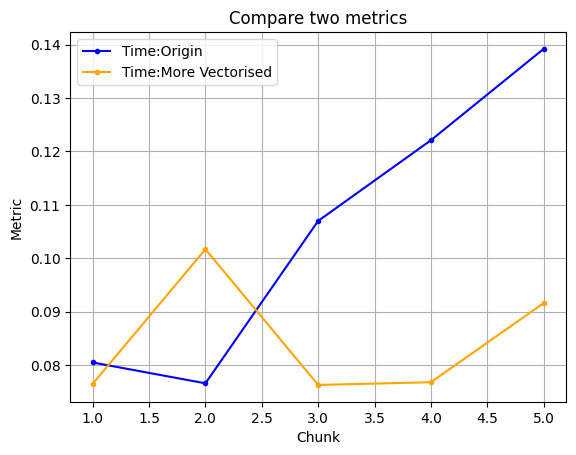

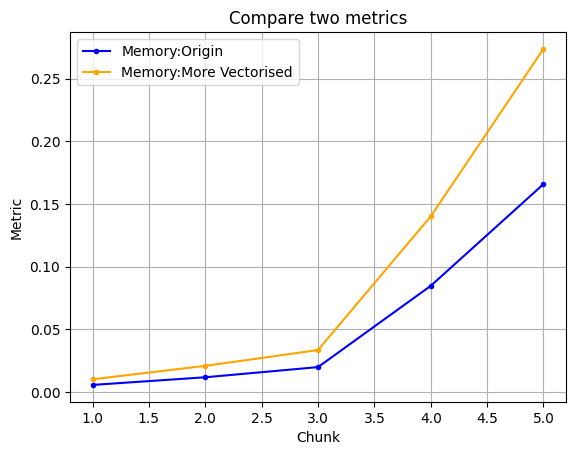

In [16]:
import sys
sys.path.append("..")

from numcompute_stream.visualise import  compare_models

compare_models(time_origin, time_vectorised, labels=['Time:Origin','Time:More Vectorised'])
compare_models(memory_origin, memory_vectorised, labels=['Memory:Origin','Memory:More Vectorised'])

# 3. Single Tree VS Ensemble(Bagging)

- The benchmark trains one ensemble bagging method(`n_estimator` = 5) and one single decision tree on the Adult dataset. The dataset is set as follows: `chunk_size` = 500, the chunk number is 10. Both use a ‘predict fisrt and then train’ strategy to simulate the real scenarios.
- As the graphic indicates, the single tree has the basic learning ability on this data set. The ensemble method has a continuously higher accuracy rate after the fifth chunk compared to the single tree. The curve becomes smoother, and the fluctuation decreases overall as the amount of data increases.
- In conclusion, the ensemble method is more **advanced** and robust compared to a single tree. 


In [7]:
from numcompute_stream.io import load_stream_csv
from numcompute_stream.stream import StreamTrainer
from numcompute_stream.pipeline import PipeLine, Preprocessor
from numcompute_stream.ensemble import EnsembleClassifier
from numcompute_stream.tree import DecisionTreeClassifier
from numcompute_stream.metrics import StreamMetrics

data_path = '../data/adult.csv'

pipe_bag = PipeLine([
    ('preprocessor',Preprocessor()),
    ('classifier',EnsembleClassifier(
        base_tree=DecisionTreeClassifier,
        n_estimators=5,
        max_depth=5,
        min_samples_split=2,
        max_features=None
    ))
])

pipe_tree = PipeLine([
    ('preprocessor',Preprocessor()),
    ('classifier',EnsembleClassifier(
        base_tree=DecisionTreeClassifier,
        n_estimators=1,
        max_depth=5,
        min_samples_split=2,
    ))
])

metrics_bag = StreamMetrics(n_class=2)
metrics_rf = StreamMetrics(n_class=2)

train_bag = StreamTrainer(pipe_bag, metrics_bag)
train_tree = StreamTrainer(pipe_tree, metrics_rf)

In [8]:
chunk_count = 0

for X_chunk, y_chunk in load_stream_csv(data_path, chunk_size=500):
    train_bag.score_chunk(X_chunk, y_chunk)
    train_tree.score_chunk(X_chunk, y_chunk)
    
    train_bag.fit_chunk(X_chunk, y_chunk)
    train_tree.fit_chunk(X_chunk, y_chunk)
    
    chunk_count += 1
    
    if chunk_count == 10:
        break

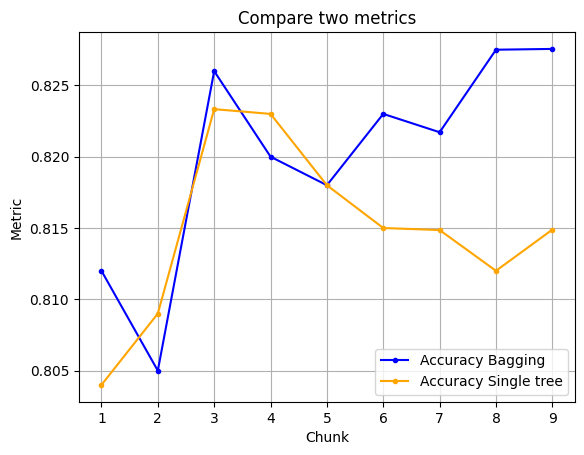

In [9]:
acc_bag = [log['accuracy'] for log in train_bag.logs]
acc_tree = [log['accuracy'] for log in train_tree.logs]

compare_models(acc_bag, acc_tree, ['Accuracy Bagging','Accuracy Single tree'])